In [ ]:
import os
import joblib
import numpy as np
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


In [ ]:
# Load full preprocessed data
X = np.load("../dataset/X.npy")
X_scaled = np.load("../dataset/X_scaled.npy")
y = np.load("../dataset/y.npy")

print("Data loaded successfully.")
print("X shape:", X.shape)


Data loaded successfully.
X shape: (64983, 21)


### 5-Fold Cross Validation
We evaluate 5 stages as requested: 1st stage 0-80% Train, 80-100% Test, etc.

In [ ]:
kf = KFold(n_splits=5, shuffle=False)

lr_scores = []
dt_scores = []
rf_scores = []
xgb_scores = []

stage = 1
for train_index, test_index in kf.split(X):
    print(f"--- STAGE {stage} ---")
    
    # Split data
    X_train, X_test = X[train_index], X[test_index]
    X_train_scaled, X_test_scaled = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train & Eval Logistic Regression
    lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
    lr_scores.append(lr_acc)
    print(f"Logistic Regression: {lr_acc:.4f}")
    
    # Train & Eval Decision Tree
    dt = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
    dt.fit(X_train, y_train)
    dt_acc = accuracy_score(y_test, dt.predict(X_test))
    dt_scores.append(dt_acc)
    print(f"Decision Tree:       {dt_acc:.4f}")
    
    # Train & Eval Random Forest
    rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10, min_samples_leaf=4, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test))
    rf_scores.append(rf_acc)
    print(f"Random Forest:       {rf_acc:.4f}")

    # Train & Eval XGBoost
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss')
    xgb.fit(X_train, y_train)
    xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
    xgb_scores.append(xgb_acc)
    print(f"XGBoost:             {xgb_acc:.4f}")

    
    print()
    stage += 1

print("=== AVERAGE ACCURACY ACROSS 5 STAGES ===")
print(f"Logistic Regression: {np.mean(lr_scores):.4f}")
print(f"Decision Tree:       {np.mean(dt_scores):.4f}")
print(f"Random Forest:       {np.mean(rf_scores):.4f}")
print(f"XGBoost:             {np.mean(xgb_scores):.4f}")


--- STAGE 1 ---
Logistic Regression: 0.8518
Decision Tree:       0.8604
Random Forest:       0.8603
XGBoost:             0.8534

--- STAGE 2 ---
Logistic Regression: 0.8293
Decision Tree:       0.7766
Random Forest:       0.8395
XGBoost:             0.8357

--- STAGE 3 ---
Logistic Regression: 0.8735
Decision Tree:       0.8864
Random Forest:       0.8864
XGBoost:             0.8795

--- STAGE 4 ---
Logistic Regression: 0.8136
Decision Tree:       0.8302
Random Forest:       0.8311
XGBoost:             0.8275

--- STAGE 5 ---
Logistic Regression: 0.8765
Decision Tree:       0.8833
Random Forest:       0.8857
XGBoost:             0.8768

=== AVERAGE ACCURACY ACROSS 5 STAGES ===
Logistic Regression: 0.8490
Decision Tree:       0.8474
Random Forest:       0.8606
XGBoost:             0.8546


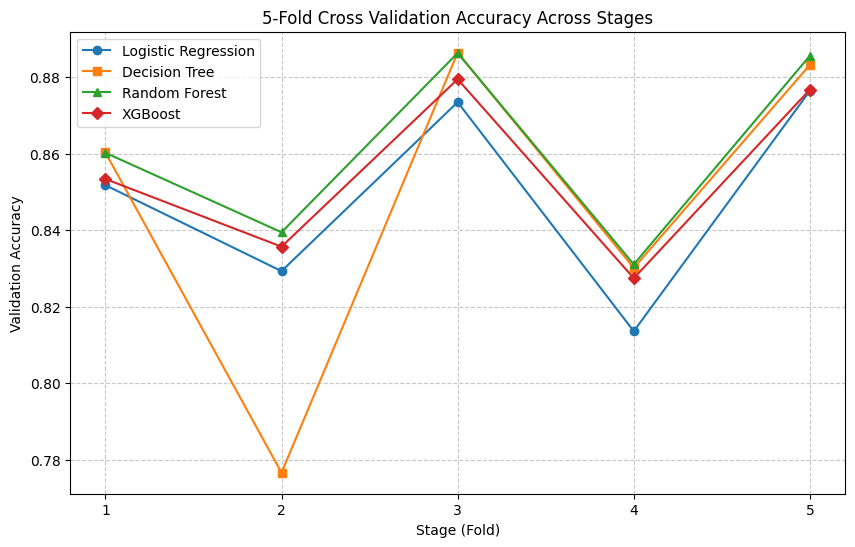

In [ ]:
import matplotlib.pyplot as plt

stages = [1, 2, 3, 4, 5]
plt.figure(figsize=(10, 6))

plt.plot(stages, lr_scores, marker='o', label='Logistic Regression')
plt.plot(stages, dt_scores, marker='s', label='Decision Tree')
plt.plot(stages, rf_scores, marker='^', label='Random Forest')
plt.plot(stages, xgb_scores, marker='D', label='XGBoost')

plt.title('5-Fold Cross Validation Accuracy Across Stages')
plt.xlabel('Stage (Fold)')
plt.ylabel('Validation Accuracy')
plt.xticks(stages)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Retrain on ALL data for the final saved models
print("Retraining final models on full dataset...")

lr_final = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_final.fit(X_scaled, y)

dt_final = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt_final.fit(X, y)

rf_final = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10, min_samples_leaf=4, random_state=42, n_jobs=-1)
rf_final.fit(X, y)


xgb_final = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_final.fit(X, y)

os.makedirs("../models", exist_ok=True)
joblib.dump(lr_final, "../models/logistic_regression.pkl")
joblib.dump(dt_final, "../models/decision_tree.pkl")
joblib.dump(rf_final, "../models/random_forest.pkl")
joblib.dump(xgb_final, "../models/xgboost.pkl")

print("All final models saved successfully.")


Retraining final models on full dataset...
All final models saved successfully.
